In [ ]:
#===== install required libraries =====
!pip -q install transformers datasets accelerate sentencepiece scikit-learn bitsandbytes -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 14.2 MB/s eta 0:00:00


In [ ]:
#===== import libraries =====
import os
import re
import gc
import json
import math
import time
import random
import warnings
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.dummy import DummyClassifier

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)

warnings.filterwarnings("ignore")

In [ ]:
#===== set seed and device =====
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
#===== load dataset files =====
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_df = pd.read_csv("sample_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (7613, 5)
Test shape: (3263, 4)
Sample submission shape: (3263, 2)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [ ]:
#===== basic data checking =====
print(train_df.columns)
print(test_df.columns)

print("\nMissing values in train:")
print(train_df.isna().sum())

print("\nClass distribution:")
print(train_df["target"].value_counts())

Index(['id', 'keyword', 'location', 'text', 'target'], dtype='object')
Index(['id', 'keyword', 'location', 'text'], dtype='object')

Missing values in train:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Class distribution:
target
0    4342
1    3271
Name: count, dtype: int64


In [ ]:
#===== text cleaning and feature combination =====
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z0-9\s!?.,]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_input_text(df):
    df = df.copy()
    df["keyword"] = df["keyword"].fillna("")
    df["location"] = df["location"].fillna("")
    df["text"] = df["text"].fillna("")

    df["combined_text"] = (
        "keyword: " + df["keyword"].astype(str) +
        " location: " + df["location"].astype(str) +
        " tweet: " + df["text"].astype(str)
    )

    df["combined_text"] = df["combined_text"].apply(clean_text)
    return df

train_df = build_input_text(train_df)
test_df = build_input_text(test_df)

display(train_df[["id", "combined_text", "target"]].head())

,id,combined_text,target
0,1,keyword location tweet our deeds are the reaso...,1
1,4,keyword location tweet forest fire near la ron...,1
2,5,keyword location tweet all residents asked to ...,1
3,6,"keyword location tweet 13,000 people receive w...",1
4,7,keyword location tweet just got sent this phot...,1


In [ ]:
#===== split training and validation data =====
train_part, val_part = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["target"]
)

train_part = train_part.reset_index(drop=True)
val_part = val_part.reset_index(drop=True)

print("Train split:", train_part.shape)
print("Validation split:", val_part.shape)

Train split: (6090, 6)
Validation split: (1523, 6)


In [ ]:
#===== evaluation helper =====
def evaluate_predictions(y_true, y_pred, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")

    print(f"\n{model_name} Results")
    print("-" * 40)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4)
    }

In [ ]:
#===== simple baseline model =====
baseline_clf = DummyClassifier(strategy="most_frequent")
baseline_clf.fit(train_part[["id"]], train_part["target"])

baseline_preds = baseline_clf.predict(val_part[["id"]])
results = []
results.append(evaluate_predictions(val_part["target"], baseline_preds, "Majority Baseline"))


Majority Baseline Results
----------------------------------------
Accuracy : 0.5706
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [ ]:
#===== FULL BERT PIPELINE (SINGLE CELL CLEAN VERSION) =====

#===== install =====
!pip -q install transformers datasets scikit-learn -U

#===== imports =====
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import re

#===== device =====
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

#===== load data =====
train_df = pd.read_csv("/content/train.csv")

#===== text cleaning =====
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

#===== combine features =====
train_df["keyword"] = train_df["keyword"].fillna("")
train_df["location"] = train_df["location"].fillna("")
train_df["text"] = train_df["text"].fillna("")

train_df["combined"] = (
    "keyword: " + train_df["keyword"] +
    " location: " + train_df["location"] +
    " tweet: " + train_df["text"]
)

train_df["combined"] = train_df["combined"].apply(clean_text)

#===== split =====
train_part, val_part = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["target"]
)

#===== tokenizer =====
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

#===== dataset (IMPORTANT: labels) =====
train_ds = Dataset.from_pandas(
    train_part[["combined", "target"]]
    .rename(columns={"combined": "text", "target": "labels"})
)

val_ds = Dataset.from_pandas(
    val_part[["combined", "target"]]
    .rename(columns={"combined": "text", "target": "labels"})
)

#===== tokenize =====
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=True, max_length=128)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)

train_ds = train_ds.remove_columns(["text"])
val_ds = val_ds.remove_columns(["text"])

train_ds.set_format("torch")
val_ds.set_format("torch")

#===== model =====
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

#===== collator =====
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#===== metrics =====
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

#===== training args =====
training_args = TrainingArguments(
    output_dir="bert_output",
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    report_to="none"
)

#===== trainer (NO tokenizer / NO label_names) =====
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

#===== train =====
trainer.train()

#===== evaluate =====
preds_output = trainer.predict(val_ds)
preds = np.argmax(preds_output.predictions, axis=1)

acc = accuracy_score(val_part["target"], preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    val_part["target"], preds, average="binary"
)

print("Accuracy :", round(acc, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.461226,0.406315,0.845043,0.892857,0.726300,0.801012
2,0.355720,0.447133,0.848326,0.851913,0.782875,0.815936


Accuracy : 0.8483
Precision: 0.8519
Recall   : 0.7829
F1 Score : 0.8159


In [ ]:
#===== load qwen small instruct model in 4-bit =====
qwen_model_name = "Qwen/Qwen2.5-0.5B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

qwen_tokenizer = AutoTokenizer.from_pretrained(qwen_model_name, trust_remote_code=True)
if qwen_tokenizer.pad_token is None:
    qwen_tokenizer.pad_token = qwen_tokenizer.eos_token

qwen_model = AutoModelForCausalLM.from_pretrained(
    qwen_model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
#===== qwen prompt based classifier =====
def build_prompt(tweet_text):
    return f"""
You are a binary text classification assistant.

Task:
Classify the tweet as:
1 = real disaster
0 = not a real disaster

Rules:
- Reply with only one number
- Reply only 0 or 1
- No explanation

Tweet:
{tweet_text}

Answer:
""".strip()

def generate_label_causal(model, tokenizer, text, max_new_tokens=3):
    prompt = build_prompt(text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    answer_part = generated_text[len(prompt):].strip()

    if "1" in answer_part and "0" not in answer_part:
        return 1
    if "0" in answer_part and "1" not in answer_part:
        return 0

    first_char = answer_part[:1]
    if first_char == "1":
        return 1
    return 0

In [ ]:
#===== run qwen on validation subset for faster comparison =====
qwen_eval_size = 300
qwen_val_sample = val_part.sample(qwen_eval_size, random_state=SEED).reset_index(drop=True)

qwen_preds = []
start_time = time.time()

for text in qwen_val_sample["combined"]:
    pred = generate_label_causal(qwen_model, qwen_tokenizer, text)
    qwen_preds.append(pred)

qwen_time = time.time() - start_time
print("Qwen evaluation time in seconds:", round(qwen_time, 2))

results.append(evaluate_predictions(qwen_val_sample["target"], qwen_preds, "Qwen2.5-0.5B-Instruct"))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Qwen evaluation time in seconds: 124.75

Qwen2.5-0.5B-Instruct Results
----------------------------------------
Accuracy : 0.5567
Precision: 0.44
Recall   : 0.4661
F1 Score : 0.4527


In [ ]:
#===== clear memory before loading tinyllama =====
del qwen_model
del qwen_tokenizer
gc.collect()
torch.cuda.empty_cache()

In [ ]:
#===== load tinyllama model in 4-bit =====
tiny_model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tiny_tokenizer = AutoTokenizer.from_pretrained(tiny_model_name)
if tiny_tokenizer.pad_token is None:
    tiny_tokenizer.pad_token = tiny_tokenizer.eos_token

tiny_model = AutoModelForCausalLM.from_pretrained(
    tiny_model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
#===== tinyllama prompt classifier (clean version) =====
def generate_label_tinyllama(model, tokenizer, text):

    prompt = f"""
You are a tweet classifier.

Return only:
1 = disaster
0 = not disaster

Tweet:
{text}

Label:
""".strip()

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256   #===== keep this here =====
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=3,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    answer = generated_text[len(prompt):].strip()

    if answer.startswith("1"):
        return 1
    else:
        return 0

In [ ]:
#===== run tinyllama on validation subset =====
tiny_eval_size = 300
tiny_val_sample = val_part.sample(tiny_eval_size, random_state=SEED).reset_index(drop=True)

tiny_preds = []
start_time = time.time()

for text in tiny_val_sample["combined"]:
    pred = generate_label_tinyllama(tiny_model, tiny_tokenizer, text)
    tiny_preds.append(pred)

tiny_time = time.time() - start_time
print("TinyLlama evaluation time in seconds:", round(tiny_time, 2))

results.append(evaluate_predictions(tiny_val_sample["target"], tiny_preds, "TinyLlama-1.1B-Chat"))

Both `max_new_tokens` (=3) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=3) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=3) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=3) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

TinyLlama evaluation time in seconds: 79.49

TinyLlama-1.1B-Chat Results
----------------------------------------
Accuracy : 0.4533
Precision: 0.4148
Recall   : 0.9492
F1 Score : 0.5773


In [ ]:
#===== show final comparison table =====
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision,Recall,F1
0,TinyLlama-1.1B-Chat,0.4533,0.4148,0.9492,0.5773
1,Qwen2.5-0.5B-Instruct,0.5567,0.4400,0.4661,0.4527
2,Majority Baseline,0.5706,0.0000,0.0000,0.0000


In [ ]:
#===== create combined column for test data =====
test_df["keyword"] = test_df["keyword"].fillna("")
test_df["location"] = test_df["location"].fillna("")
test_df["text"] = test_df["text"].fillna("")

test_df["combined"] = (
    "keyword: " + test_df["keyword"] +
    " location: " + test_df["location"] +
    " tweet: " + test_df["text"]
)

test_df["combined"] = test_df["combined"].apply(clean_text)

In [ ]:
#===== reload bert tokenizer =====
from transformers import AutoTokenizer

bert_model_name = "distilbert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

print("Tokenizer loaded successfully")

Tokenizer loaded successfully


In [ ]:
#===== create combined column for test data =====
test_df["keyword"] = test_df["keyword"].fillna("")
test_df["location"] = test_df["location"].fillna("")
test_df["text"] = test_df["text"].fillna("")

test_df["combined"] = (
    "keyword: " + test_df["keyword"].astype(str) +
    " location: " + test_df["location"].astype(str) +
    " tweet: " + test_df["text"].astype(str)
)

test_df["combined"] = test_df["combined"].apply(clean_text)

#===== prepare full test dataset for bert prediction =====
from datasets import Dataset

test_texts = test_df[["combined"]].rename(columns={"combined": "text"})
test_ds = Dataset.from_pandas(test_texts)

def bert_tokenize_test(batch):
    return bert_tokenizer(batch["text"], truncation=True, max_length=128)

test_ds = test_ds.map(bert_tokenize_test, batched=True)
test_ds = test_ds.remove_columns(["text"])
test_ds.set_format("torch")

print(test_ds)

Map:   0%|          | 0/3263 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3263
})


In [ ]:
#===== predict on kaggle test set =====
test_outputs = trainer.predict(test_ds)
test_preds = np.argmax(test_outputs.predictions, axis=1)

submission_df = pd.DataFrame({
    "id": test_df["id"],
    "target": test_preds
})

print(submission_df.head())

   id  target
0   0       1
1   2       1
2   3       1
3   9       1
4  11       1


In [ ]:
#===== save submission file =====
submission_path = "disaster_tweet_submission.csv"
submission_df.to_csv(submission_path, index=False)
print("Saved:", submission_path)

Saved: disaster_tweet_submission.csv


In [ ]:
#===== save comparison results =====
results_path = "model_comparison_results.csv"
results_df.to_csv(results_path, index=False)
print("Saved:", results_path)

Saved: model_comparison_results.csv


In [ ]:
#===== bert validation report =====
import numpy as np
from sklearn.metrics import classification_report

bert_outputs = trainer.predict(val_ds)
bert_preds = np.argmax(bert_outputs.predictions, axis=1)

print(classification_report(val_part["target"], bert_preds, digits=4))

              precision    recall  f1-score   support

           0     0.8460    0.8976    0.8710       869
           1     0.8519    0.7829    0.8159       654

    accuracy                         0.8483      1523
   macro avg     0.8490    0.8402    0.8435      1523
weighted avg     0.8485    0.8483    0.8474      1523



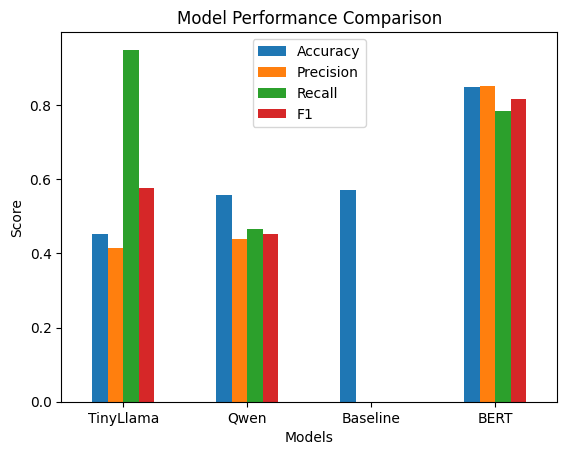

In [ ]:
#===== model comparison bar plot =====
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame([
    ["TinyLlama", 0.4533, 0.4148, 0.9492, 0.5773],
    ["Qwen", 0.5567, 0.4400, 0.4661, 0.4527],
    ["Baseline", 0.5706, 0.0000, 0.0000, 0.0000],
    ["BERT", 0.8483, 0.8519, 0.7829, 0.8159]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

results_df.set_index("Model").plot(kind="bar")
plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.show()

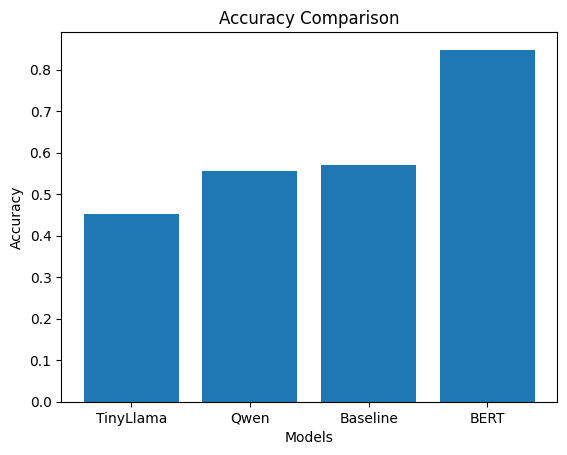

In [ ]:
#===== accuracy comparison plot =====
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

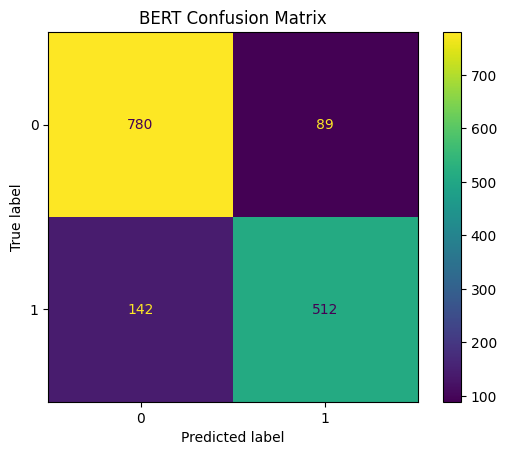

In [ ]:
#===== confusion matrix =====
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(val_part["target"], bert_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("BERT Confusion Matrix")
plt.show()

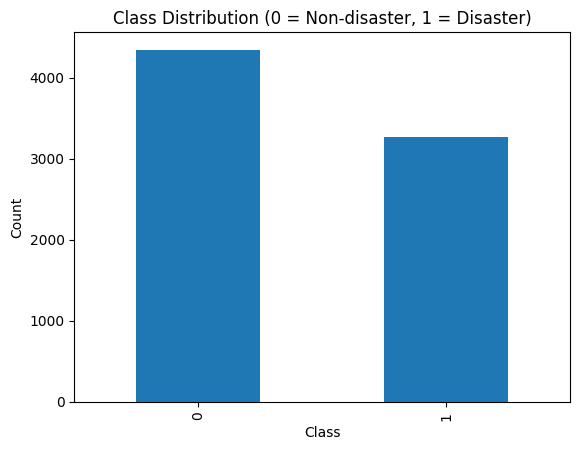

In [ ]:
#===== class distribution =====
train_df["target"].value_counts().plot(kind="bar")
plt.title("Class Distribution (0 = Non-disaster, 1 = Disaster)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

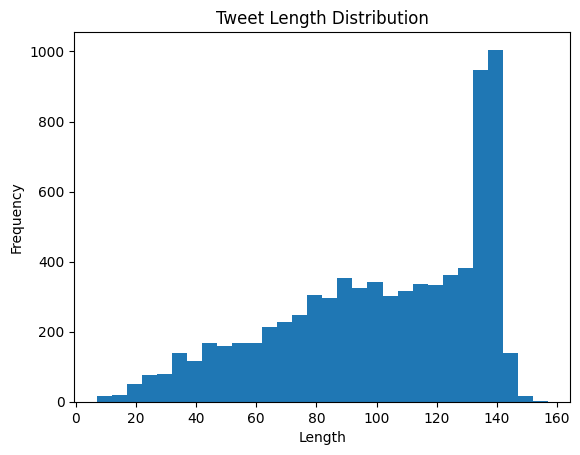

In [ ]:
#===== tweet length distribution =====
train_df["length"] = train_df["text"].apply(lambda x: len(str(x)))

plt.figure()
plt.hist(train_df["length"], bins=30)
plt.title("Tweet Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()